In [1]:
#Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [3]:
#Load the Dataset
df = pd.read_csv("/content/drive/MyDrive/Dataset/DataCoSupplyChainDataset.csv", encoding="latin1")
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [4]:
#Check the shape
df.shape

(180519, 53)

In [5]:
#Reduce Dataset Size
df = df.sample(50000, random_state=42)

In [6]:
#Convert Date Columns
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"])
df["shipping date (DateOrders)"] = pd.to_datetime(df["shipping date (DateOrders)"])

In [7]:
df["order_month"] = df["order date (DateOrders)"].dt.month
df["shipping_month"] = df["shipping date (DateOrders)"].dt.month

In [8]:
df = df.drop(columns=[
"order date (DateOrders)",
"shipping date (DateOrders)"
])

In [9]:
#Remove Useless Columns
df = df.drop(columns=[
"Customer Email",
"Customer Password",
"Customer Fname",
"Customer Lname",
"Customer Street",
"Product Description",
"Product Image",
"Product Name",
"Customer City",
"Order City"
])

In [10]:
#Select Important Features
features = [
"Days for shipping (real)",
"Days for shipment (scheduled)",
"Shipping Mode",
"Order Region",
"Order Item Quantity",
"Order Item Product Price",
"Order Item Discount Rate",
"order_month",
"shipping_month"
]

X = df[features]
y = df["Late_delivery_risk"]

In [11]:
#Convert Text Columns to Numbers
X = pd.get_dummies(X)

In [12]:
#Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
#Train Model
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [14]:
#Test Model
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9756


#Logistic Regression (Baseline)

In [15]:
#predicting Late_delivery_risk (a classification problem)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9788


#Decision Tree

In [16]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9477


#XGBoost

In [18]:
from xgboost import XGBClassifier

model = XGBClassifier()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9786


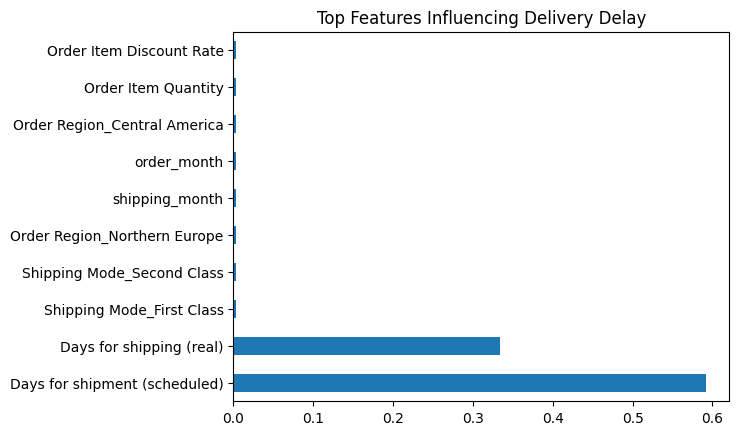

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_

feature_importance = pd.Series(importance, index=X_train.columns)

feature_importance.nlargest(10).plot(kind='barh')

plt.title("Top Features Influencing Delivery Delay")
plt.show()

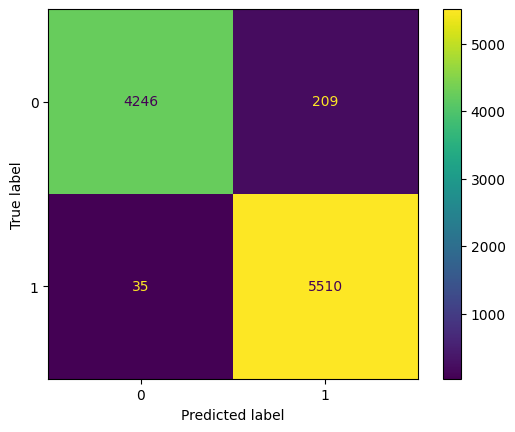

In [20]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()

In [21]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      4455
           1       0.96      0.99      0.98      5545

    accuracy                           0.98     10000
   macro avg       0.98      0.97      0.98     10000
weighted avg       0.98      0.98      0.98     10000



#Late Delivery Distribution

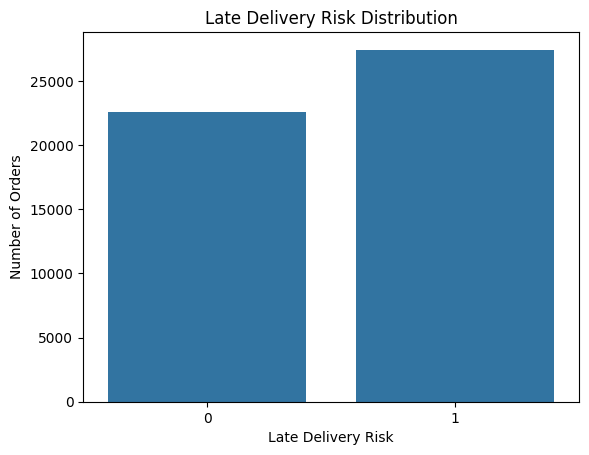

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Late_delivery_risk", data=df)

plt.title("Late Delivery Risk Distribution")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Number of Orders")

plt.show()

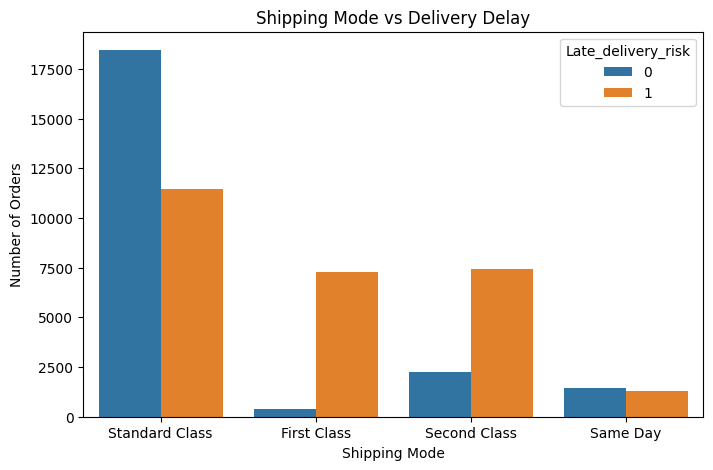

In [23]:
#Shipping Mode vs Delay Risk
plt.figure(figsize=(8,5))

sns.countplot(x="Shipping Mode", hue="Late_delivery_risk", data=df)

plt.title("Shipping Mode vs Delivery Delay")
plt.xlabel("Shipping Mode")
plt.ylabel("Number of Orders")

plt.show()

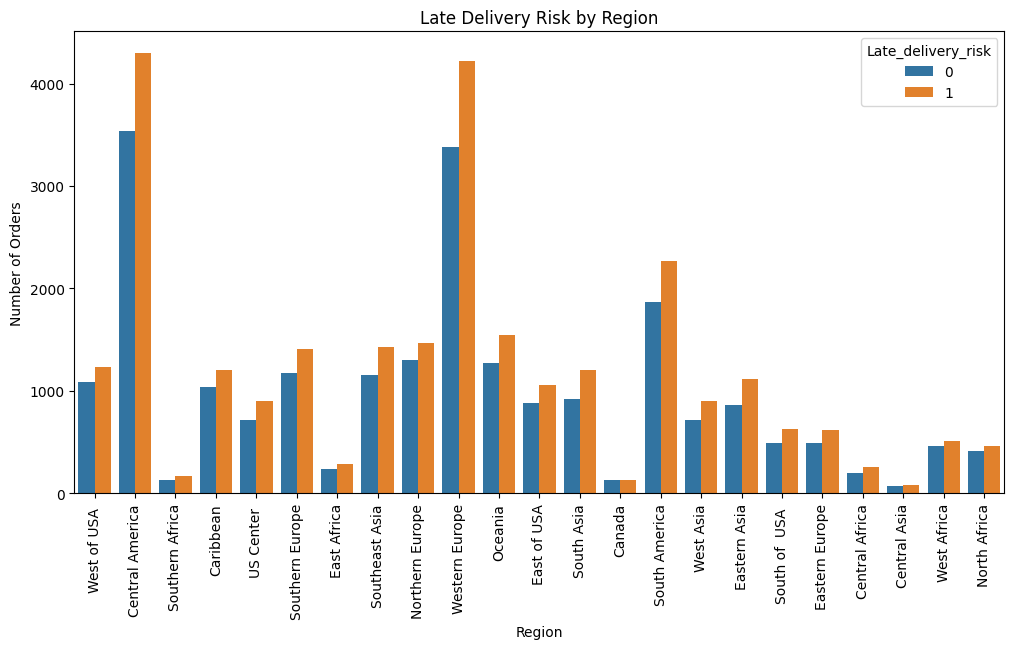

In [24]:
#Regional Delay Analysis
plt.figure(figsize=(12,6))

sns.countplot(x="Order Region", hue="Late_delivery_risk", data=df)

plt.xticks(rotation=90)

plt.title("Late Delivery Risk by Region")
plt.xlabel("Region")
plt.ylabel("Number of Orders")

plt.show()

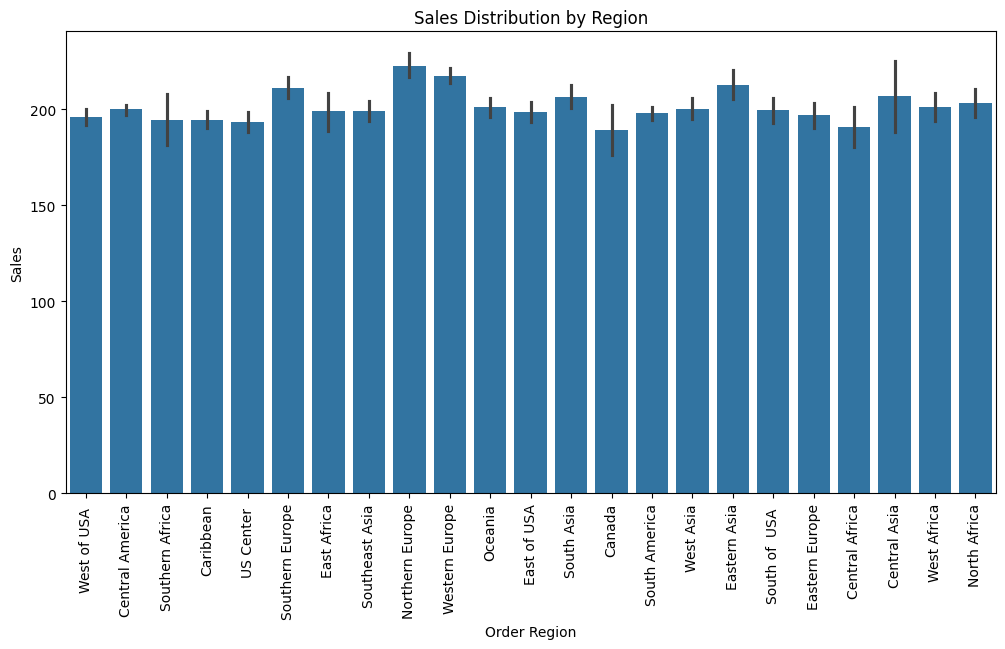

In [25]:
#Sales by Region
plt.figure(figsize=(12,6))

sns.barplot(x="Order Region", y="Sales", data=df)

plt.xticks(rotation=90)

plt.title("Sales Distribution by Region")

plt.show()

#Demand Forecasting Model

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

features = [
"Product Price",
"Order Item Discount Rate",
"order_month",
"shipping_month"
]

X = df[features]
y = df["Order Item Quantity"]

X = pd.get_dummies(X)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestRegressor()

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test,pred))

MAE: 0.7385669687326195


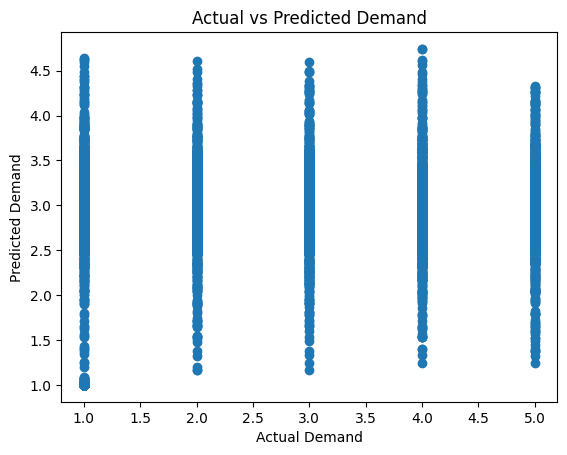

In [27]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")

plt.show()

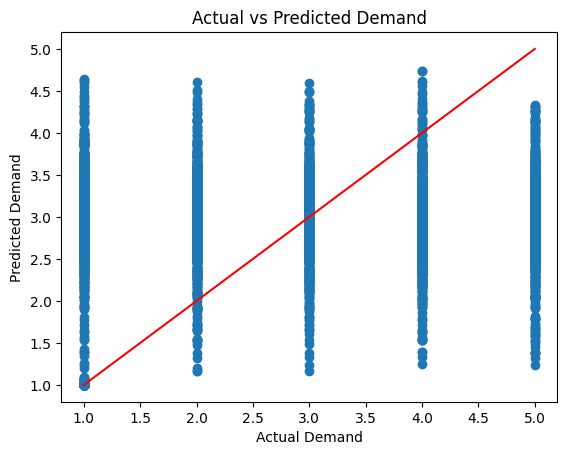

In [28]:
import numpy as np

plt.scatter(y_test, pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")

plt.show()